In [1]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.analytics.db_connector import populate_financials, query_financials

df = pd.read_csv("../data/processed/cleaned/cleaned_data.csv")
print(f"Loaded {len(df)} rows")
print(df.columns.tolist())

Loaded 11 rows
['source', 'fetched_at', 'version', '_collection', 'data.make', 'data.model', 'data.year', 'data.recalls', 'data.file_name', 'data.document_type', 'data.source', 'data.extraction_timestamp', 'data.extraction_library', 'data.scraped_at', 'data.type', 'data.title', 'data.description', 'data.price', 'data.link', 'data.page', 'data.original_path', 'data.resized_path', 'data.thumbnail_path', 'data.webp_path', 'data.format', 'data.mode', 'data.width', 'data.height', 'data.file_size_kb', 'data.exif.file_name', 'data.exif.camera_make', 'data.exif.camera_model', 'data.exif.date_taken', 'data.exif.exposure_time', 'data.exif.aperture', 'data.exif.iso', 'data.exif.focal_length', 'data.exif.orientation', 'data.exif.gps', 'data.exif.extracted_at', 'data.processed_at', 'release_year']


In [2]:
populate_financials(df)

import sqlalchemy
engine = sqlalchemy.create_engine("mysql+pymysql://root:@localhost/automotive_tracker")
df_mysql = pd.read_sql("SELECT * FROM vehicle_financials WHERE year IS NOT NULL", engine)
print(f"MySQL rows: {len(df_mysql)}")
df_mysql.head()

MySQL rows: 121


,id,make,model,year,recall_count,source,version,collection_name,release_year,fetched_at
0,1,Audi,A4,2020,0,test,1.0,raw_recalls,2026,2026-03-23 22:57:44.926
1,2,Skoda,OCTAVIA,2020,0,nhtsa_api,1.0,raw_recalls,2026,2026-03-23 23:02:08.429
2,3,Unknown,UNKNOWN,2020,0,pdf_extraction,1.0,raw_recalls,2026,2026-03-29 20:52:52.608
3,4,Unknown,UNKNOWN,2020,0,word_extraction,1.0,raw_recalls,2026,2026-03-29 21:02:26.591
4,5,Unknown,UNKNOWN,2020,0,excel_extraction,1.0,raw_recalls,2026,2026-03-29 21:05:48.985


In [3]:
df_clean = df[~df["data.make"].isin(["Unknown", "UNKNOWN"])].copy()
print(f"Rows after filtering Unknown: {len(df_clean)}")
df_clean["data.make"].value_counts()

Rows after filtering Unknown: 3


data.make
Audi     2
Skoda    1
Name: count, dtype: int64

In [4]:
from src.analytics.data_combiner import merge_dataframes, compare_join_types, concat_dataframes

df_mongo_style = df_clean[["data.make", "data.model", "data.year", "source", "release_year"]].copy()
df_mongo_style.columns = ["make", "model", "year", "source", "release_year"]

df_mysql_clean = df_mysql[df_mysql["make"] != "Unknown"].copy()

join_counts = compare_join_types(df_mongo_style, df_mysql_clean, on="make")
print("Join type row counts:")
for join_type, count in join_counts.items():
    print(f"  {join_type}: {count} rows")

Join type row counts:
  inner: 55 rows
  left: 55 rows
  right: 55 rows
  outer: 55 rows


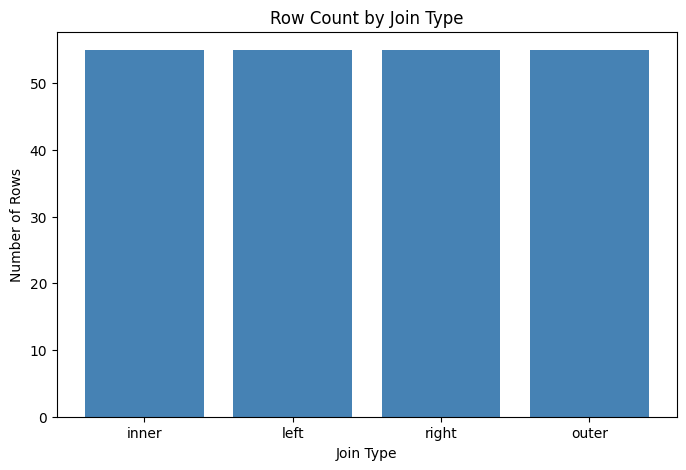

Chart saved.


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(join_counts.keys(), join_counts.values(), color="steelblue")
plt.title("Row Count by Join Type")
plt.xlabel("Join Type")
plt.ylabel("Number of Rows")
plt.savefig("../data/processed/analytics/join_comparison.png")
plt.show()
print("Chart saved.")

In [ ]:
from src.analytics.pivot_builder import wide_to_long, build_pivot_table, build_crosstab

df_combined = merge_dataframes(df_mongo_style, df_mysql_clean, on="make", how="inner")

long_df = wide_to_long(
    df_combined,
    id_vars=["make", "model_x", "year_x"],
    value_vars=["recall_count", "version", "release_year"]
)
print(f"Long format rows: {len(long_df)}")
long_df.head()